## Exercise 3

In [71]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

**Task 1**

In [64]:
def exponentialDist(n, lam):
    U = np.random.uniform(size=n)
    Y = -np.log(U) / lam
    return Y

def box_muller(n):
    U_1 = np.random.uniform(size=n)
    U_2 = np.random.uniform(size=n)
    R = np.sqrt(-2 * np.log(U_1))
    theta = 2 * np.pi * U_2
    X = R * np.cos(theta)
    Y = R * np.sin(theta)
    return X, Y

def pareto(k,beta, n):
    U = np.random.uniform(size=n)
    X = beta * (U**(-1/k))
    return X



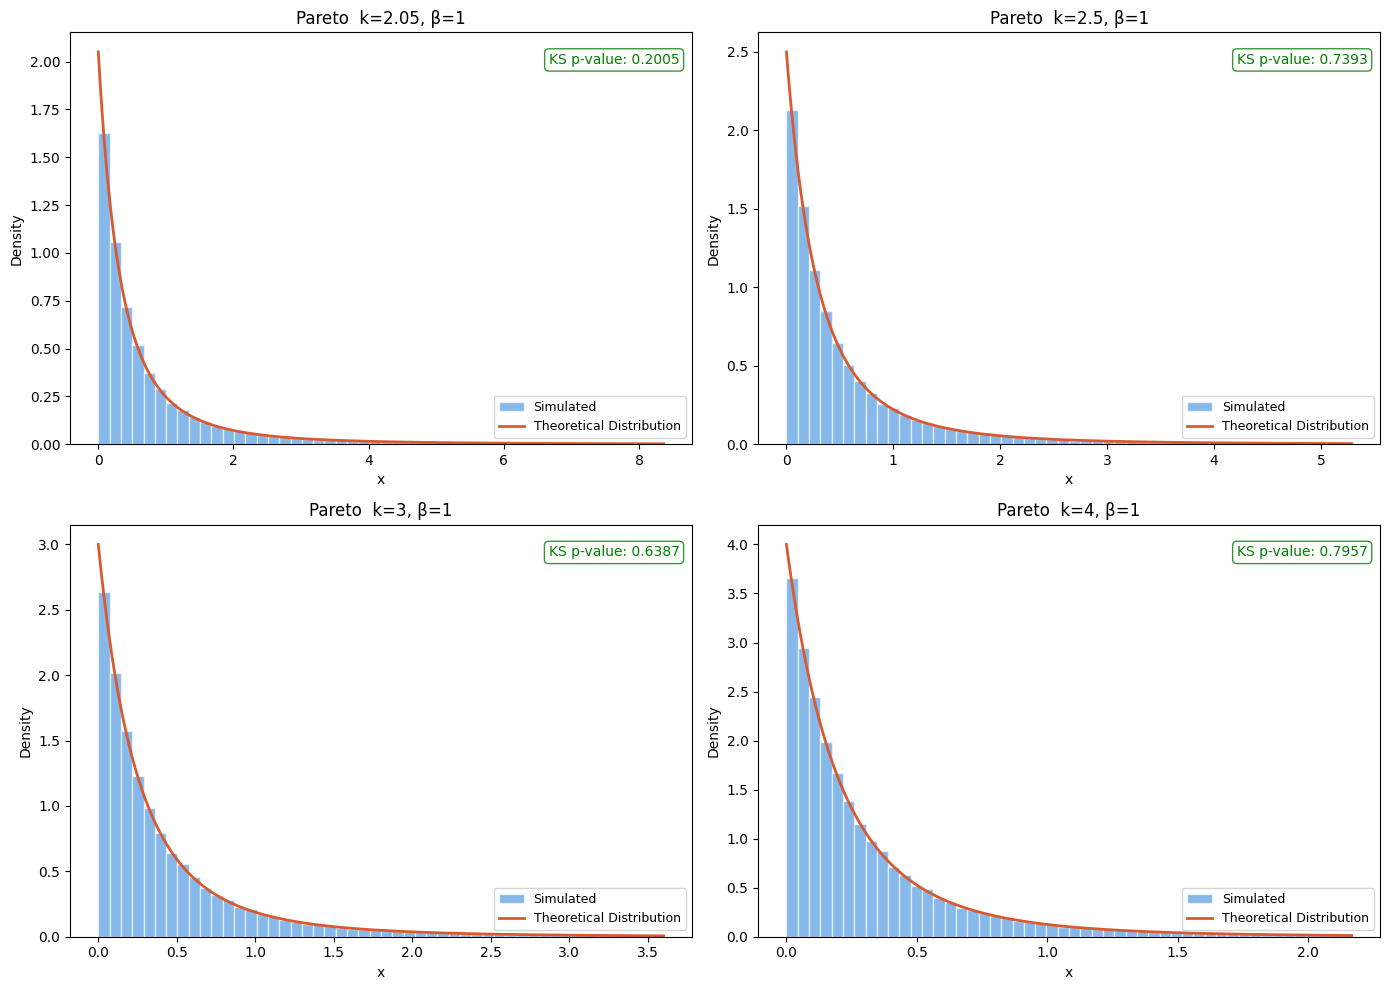

In [ ]:
# Experiment with different k's
K = [2.05, 2.5, 3, 4]
beta = 1
n = 10000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Histogram plot for each k
for idx, k in enumerate(K):
    x = pareto(k, beta, n)
    ax = axes[idx]

    cdf_func = lambda t: 1 - (beta / (t + beta))**k
    ks = stats.kstest(x, cdf_func)
    pdf_func = lambda t: (k * beta**k) / (t + beta)**(k+1)

    x_clip = np.percentile(x, 99)
    x_plot = x[x <= x_clip]

    ax.hist(x_plot, bins=50, density=True, alpha=0.6,
            color='#378ADD', edgecolor='white', label='Simulated')

    t = np.linspace(0, x_clip, 10000)
    ax.plot(t, pdf_func(t), color='#D85A30', linewidth=2, label='Theoretical Distribution')

    color = 'green' if ks.pvalue > 0.05 else 'red'
    ax.annotate(f'KS p-value: {ks.pvalue:.4f}', xy=(0.98, 0.95),
                xycoords='axes fraction', ha='right', va='top',
                fontsize=10, color=color,
                bbox=dict(boxstyle='round,pad=0.3', edgecolor=color,
                          facecolor='white', alpha=0.8))
    ax.set_title(f'Pareto  k={k}, β={beta}')
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# Histogram plot for exponential and normal methods
def verify_all(exp_samples, normal_samples, lam):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    configs = [
        (axes[0], exp_samples,    'Exponential',
         lambda x: lam * np.exp(-lam * x),
         stats.kstest(exp_samples, 'expon', args=(0, 1/lam))),
        
        (axes[1], normal_samples, 'Normal (Box-Muller)',
         lambda x: stats.norm.pdf(x, 0, 1),
         stats.kstest(normal_samples, 'norm'))
    ]

    for ax, samples, title, pdf_func, ks in configs:
        ax.hist(samples, bins=50, density=True, alpha=0.6,
                color='#378ADD', edgecolor='white', label='Simulated')
        x = np.linspace(min(samples), max(samples), 10000)
        ax.plot(x, pdf_func(x), color='#D85A30', linewidth=2, label='Theoretical PDF')
        color = 'green' if ks.pvalue > 0.05 else 'red'
        ax.annotate(f'KS p-value: {ks.pvalue:.4f}', xy=(0.98, 0.95),
                    xycoords='axes fraction', ha='right', va='top',
                    fontsize=10, color=color,
                    bbox=dict(boxstyle='round,pad=0.3', edgecolor=color,
                              facecolor='white', alpha=0.8))
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('Density')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

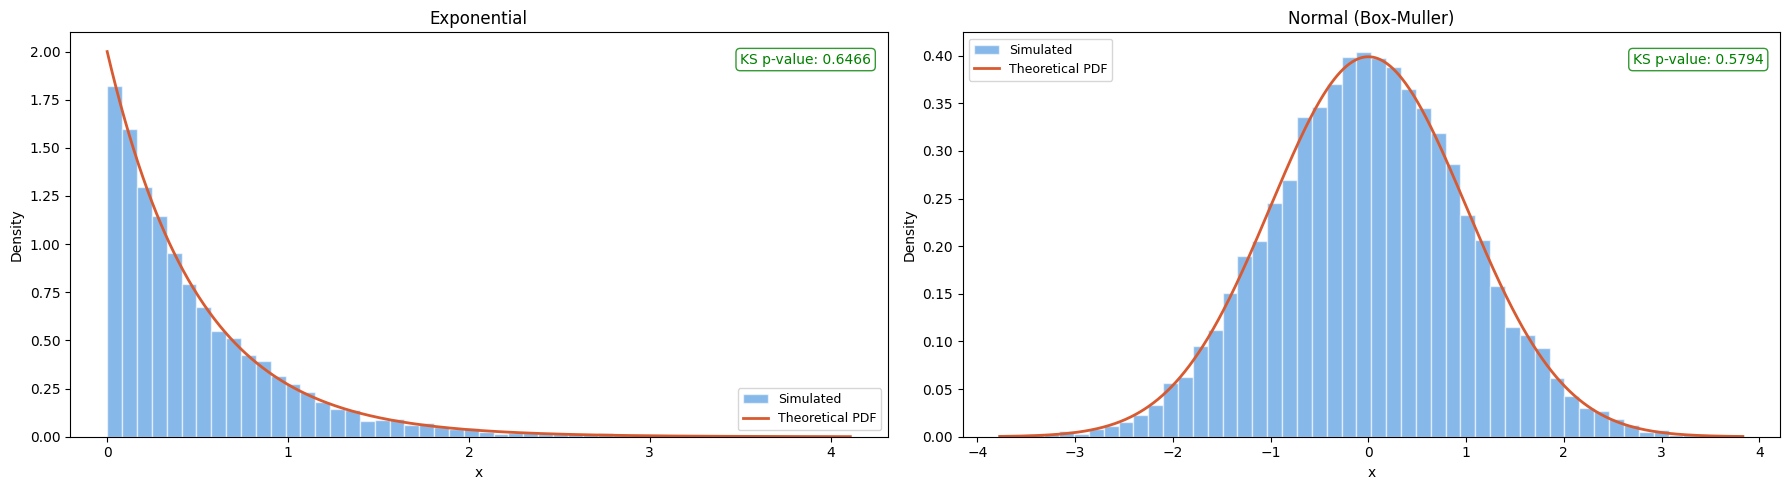

In [30]:
Y = exponentialDist(n=10000, lam=2)
X, _ = box_muller(n=10000)

verify_all(Y, X, lam=2)

**Task 2**

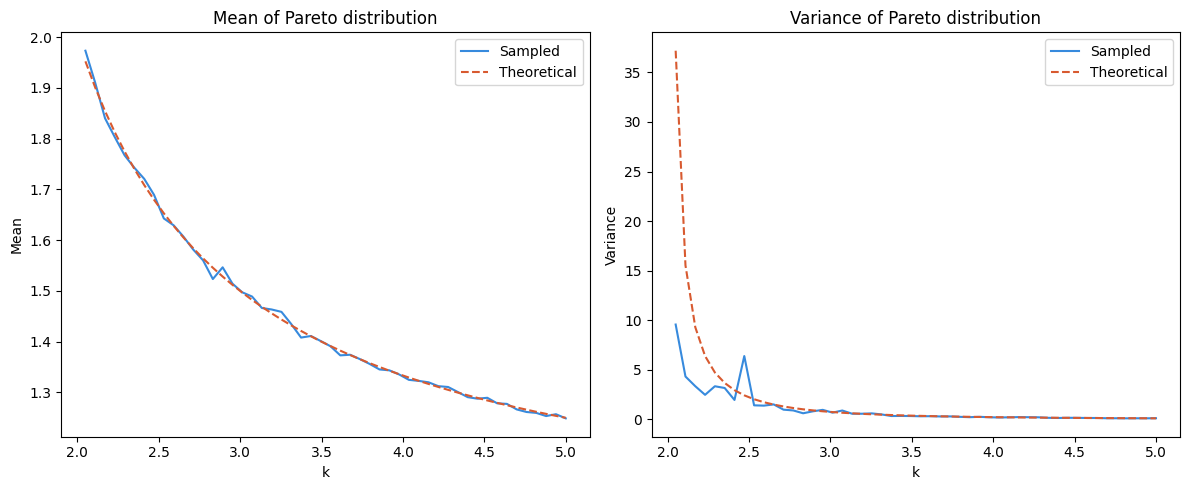

[ 6.68  9.33 10.69  9.44  6.25  6.03  6.5   8.55  6.5   6.95 10.75  6.68
  6.98  7.03  6.97  6.97  8.5   6.28 10.5   6.28]


In [ ]:
# 50 values of k to get a cleaner slope
K = np.linspace(2.05, 5, 50)
mean_sample=[]
mean_theory=[]

var_sample = []
var_theory = []

for k in K:
    x = pareto(k, beta=1, n=10000)

    #Sampled calculations
    I = np.mean(x)
    J = np.var(x, ddof=1)

    #Theoretical Calculations
    E = np.dot(beta, k/(k-1))
    V = np.dot(beta**2, k/(np.dot((k-1)**2,(k-2))))

    mean_sample.append(I)
    var_sample.append(J)
    mean_theory.append(E)
    var_theory.append(V)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mean
axes[0].plot(K, mean_sample, '-', color='#378ADD', label='Sampled')
axes[0].plot(K, mean_theory, '--', color='#D85A30', label='Theoretical')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Mean')
axes[0].set_title('Mean of Pareto distribution')
axes[0].legend()

# Variances
axes[1].plot(K, var_sample, '-', color='#378ADD', label='Sampled')
axes[1].plot(K, var_theory, '--', color='#D85A30', label='Theoretical')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Variance')
axes[1].set_title('Variance of Pareto distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# Trying n=1000000
variances = [np.var(pareto(k=2.1, beta=1, n=1000000), ddof=1) for _ in range(20)]
print(np.round(variances, 2))  # some are closer to theoretical, but still noisy


**Task 3**

                                  Mean CI   Variance CI
--------------------------------------------------------
Coverage (%)                         95.0          96.0
Target (%)                           95.0          95.0
Misses                                  5             4


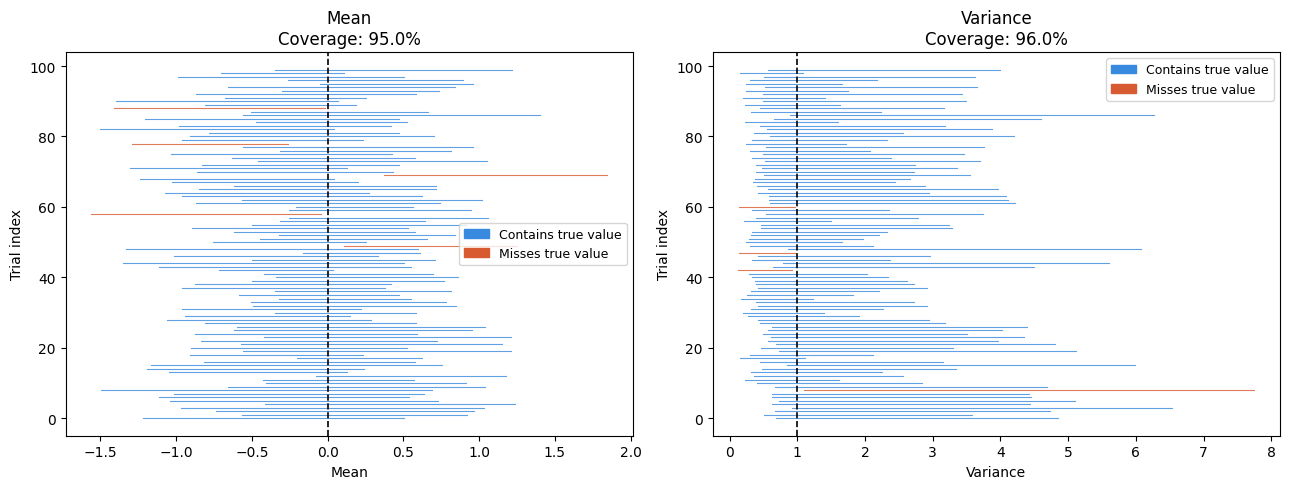

In [ ]:
mean_CIs = []
var_CIs = []
N_trials = 100

for _ in range(N_trials):
    X, _ = box_muller(n=10)

    # Mean Calculation
    x_bar = np.mean(X)
    s = np.std(X, ddof=1)
    t = stats.t.ppf(0.975, df=9)  #split the 5% equally in both tails (2.5% each side)

    mean_CIs.append((x_bar - t*s/np.sqrt(10), x_bar + t*s/np.sqrt(10)))

    #Variance calculation
    s2 = s**2
    chi2_low = stats.chi2.ppf(0.025, df=9)
    chi2_high = stats.chi2.ppf(0.975, df=9)
    
    var_CIs.append((9*s2 / chi2_high, 9*s2 / chi2_low))

# Check coverage
mean_hits = [lo <= 0 <= hi for lo, hi in mean_CIs]
var_hits  = [lo <= 1 <= hi for lo, hi in var_CIs]
mean_coverage = np.mean(mean_hits) * 100
var_coverage  = np.mean(var_hits)  * 100

# Summary table
print(f"{'':30s} {'Mean CI':>10s}  {'Variance CI':>12s}")
print("-" * 56)
print(f"{'Coverage (%)':30s} {mean_coverage:>10.1f}  {var_coverage:>12.1f}")
print(f"{'Target (%)':30s} {'95.0':>10s}  {'95.0':>12s}")
print(f"{'Misses':30s} {N_trials - sum(mean_hits):>10d}  {N_trials - sum(var_hits):>12d}")

# Confidence intervals plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, CIs, hits, true_val, label in zip(
    axes,
    [mean_CIs, var_CIs],
    [mean_hits, var_hits],
    [0, 1],
    ['Mean', 'Variance']
):
    for i, ((lo, hi), hit) in enumerate(zip(CIs[:N_trials], hits[:N_trials])):
        color = '#378ADD' if hit else '#D85A30'
        ax.plot([lo, hi], [i, i], color=color, lw=0.8, alpha=0.8)

    ax.axvline(true_val, color='black', lw=1.2, linestyle='--', label=f'True value = {true_val}')
    ax.set_xlabel(label)
    ax.set_ylabel('Trial index')
    ax.set_title(f'{label}\nCoverage: {np.mean(hits)*100:.1f}%')

    hit_patch  = mpatches.Patch(color='#378ADD', label='Contains true value')
    miss_patch = mpatches.Patch(color='#D85A30', label='Misses true value')
    ax.legend(handles=[hit_patch, miss_patch], fontsize=9)

plt.tight_layout()
plt.show()

**Task 4**

KS p-value: 0.6761


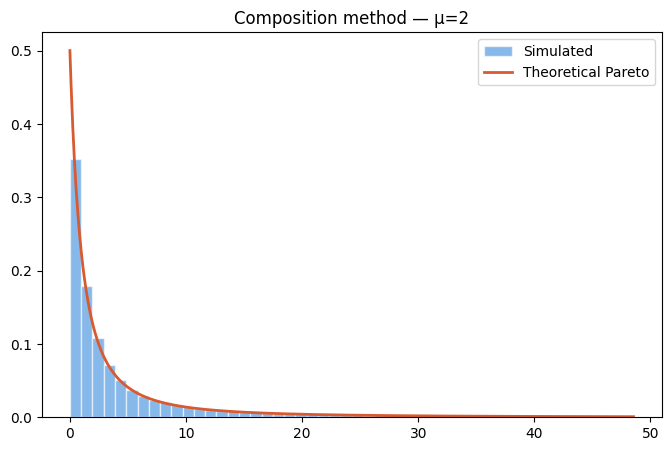

In [ ]:
mu = 2
n = 100000

# Start from a an exponential mixing distribution
Y = exponentialDist(n, lam=mu)
# Then an exponential conditional
X = np.array([exponentialDist(1, lam=float(y)) for y in Y])

cdf_func = lambda t: 1 - (1 + t/mu)**(-1)
ks = stats.kstest(X.flatten(), cdf_func)
print(f"KS p-value: {float(ks.pvalue):.4f}")

fig, ax = plt.subplots(figsize=(8, 5))

x_clip = np.percentile(X, 96)
X_plot = X[X <= x_clip]

ax.hist(X_plot, bins=50, density=True, alpha=0.6,
        color='#378ADD', edgecolor='white', label='Simulated')
        
t = np.linspace(0, x_clip, 1000)
pdf = mu / (mu + t)**2
ax.plot(t, pdf, color='#D85A30', linewidth=2, label='Theoretical Pareto')

ax.set_title(f'Composition method — μ={mu}')
ax.legend()
plt.show()
